 ## 1. Load Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_curve
)
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")



 ## 2. Load Data

In [ ]:
df = pd.read_csv("new_df.csv")

target_col = "chagas"

X = df.drop(columns=[target_col])
y = df[target_col]
groups = df["patient_id"]

print("Dataset size:", df.shape)

print("\nTarget variable distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))




Dataset size: (342142, 42)

Target variable distribution:
chagas
0    335583
1      6559
Name: count, dtype: int64

Target proportions:
chagas
0    0.98083
1    0.01917
Name: proportion, dtype: float64

Target unique values:
[np.int64(0), np.int64(1)]


 ## 3. Train / Validation / Test Split by Patient

In [3]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_temp = X.iloc[temp_idx].copy()

y_train = y.iloc[train_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()

y_val = y_temp.iloc[val_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

groups_val = groups_temp.iloc[val_idx].copy()
groups_test = groups_temp.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (239583, 41)
Validation: (51312, 41)
Test: (51247, 41)


 ## 4. Check Patient Overlap Between Splits

In [ ]:
train_patients = set(groups_train)
val_patients = set(groups_val)
test_patients = set(groups_test)

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))

PATIENT OVERLAP CHECK
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
No patient overlap between train, validation and test sets


 ## 5. XGBoost Data Checks and Preprocessing

In [ ]:
drop_cols = [
    "exam_id",
    "patient_id",
    "interval_lead_idx",
    "n_usable_leads"
]

drop_cols = [
    col for col in drop_cols
    if col in X_train.columns
]

X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

for data_part in [X_train, X_val, X_test]:
    bool_cols = data_part.select_dtypes(include=["bool"]).columns
    data_part[bool_cols] = data_part[bool_cols].astype(int)


object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())


XGBOOST DATA CHECKS

Data types in training set:
float64    29
int64       8
Name: count, dtype: int64

No object columns detected

Missing values in training set:
       Feature  Missing values  Missing proportion (%)
  qrs_duration            1187                0.495444
   qt_interval            1165                0.486262
   pr_interval             714                0.298018
 hrv_rmssd_std              58                0.024209
hrv_rmssd_mean              14                0.005843
   rr_mean_std              13                0.005426
    rr_std_std              13                0.005426
          sdnn              10                0.004174
         pnn50              10                0.004174
   rr_std_mean               8                0.003339
  rr_mean_mean               8                0.003339

Missing values are kept as NaN because XGBoost can handle them internally.

Missing values:
Train: 3200
Validation: 651
Test: 672

Features used for modelling: 37
Training sam

 ## 6. Class Balance Check

In [ ]:
print(f"Train positive rate: {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"Validation positive rate: {y_val.mean():.4f} ({y_val.sum()}/{len(y_val)})")
print(f"Test positive rate: {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")

n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight_value = n_negative / n_positive
sqrt_scale_pos_weight_value = np.sqrt(scale_pos_weight_value)

print("\nClass imbalance ratio:")
print(f"Negative / positive ratio: {scale_pos_weight_value:.4f}")
print(f"Square root ratio: {sqrt_scale_pos_weight_value:.4f}")



TARGET CLASS BALANCE ACROSS SPLITS
Train positive rate: 0.0186 (4450/239583)
Validation positive rate: 0.0218 (1120/51312)
Test positive rate: 0.0193 (989/51247)

Train class proportions:
chagas
0    0.981426
1    0.018574
Name: proportion, dtype: float64

Validation class proportions:
chagas
0    0.978173
1    0.021827
Name: proportion, dtype: float64

Test class proportions:
chagas
0    0.980701
1    0.019299
Name: proportion, dtype: float64

Class imbalance ratio:
Negative / positive ratio: 52.8389
Square root ratio: 7.2690


 ## 7. Helper Function for F2 Threshold Selection

In [7]:
def get_best_f2_threshold(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    beta_squared = beta ** 2

    f2_scores = (
        (1 + beta_squared) * precision[:-1] * recall[:-1] /
        (beta_squared * precision[:-1] + recall[:-1] + 1e-9)
    )

    best_idx = np.argmax(f2_scores)

    return {
        "threshold": thresholds[best_idx],
        "f2": f2_scores[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }



 ## 8. Hyperparameter Tuning with Hold-Out Validation

In [ ]:
param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05, 0.10],
    "subsample": [0.3, 0.8, 1.0],
    "colsample_bytree": [0.3, 0.8, 1.0],
    "min_child_weight": [1, 5],
    "scale_pos_weight": [
        sqrt_scale_pos_weight_value,
        scale_pos_weight_value
    ]
}

total_combinations = len(ParameterGrid(param_grid))

print(f"Parameter combinations: {total_combinations} models")
print("Model selection metric: Validation PR-AUC")
print("Threshold selection metric: Validation F2-score")
print("ROC-AUC is reported as an additional discrimination metric\n")



XGBOOST HYPERPARAMETER GRID SEARCH - HOLD-OUT VALIDATION
Parameter combinations: 648 models
Model selection metric: Validation PR-AUC
Threshold selection metric: Validation F2-score
ROC-AUC is reported as an additional discrimination metric



In [ ]:
results = []

best_score = -np.inf
best_model = None
best_params = None
best_threshold = None


for params in tqdm(ParameterGrid(param_grid), total=total_combinations, desc="XGBoost Grid Search"):

    xgb = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train, y_train)

    y_val_prob = xgb.predict_proba(X_val)[:, 1]

    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    y_val_pred_default = (y_val_prob >= 0.5).astype(int)

    val_balanced_acc_default = balanced_accuracy_score(
        y_val,
        y_val_pred_default
    )

    val_f1_default = f1_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_f2_default = fbeta_score(
        y_val,
        y_val_pred_default,
        beta=2,
        zero_division=0
    )

    val_precision_default = precision_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_recall_default = recall_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    threshold_info = get_best_f2_threshold(
        y_val,
        y_val_prob,
        beta=2
    )

    selected_threshold = threshold_info["threshold"]

    y_val_pred_selected = (
        y_val_prob >= selected_threshold
    ).astype(int)

    val_balanced_acc_selected = balanced_accuracy_score(
        y_val,
        y_val_pred_selected
    )

    val_f1_selected = f1_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_f2_selected = fbeta_score(
        y_val,
        y_val_pred_selected,
        beta=2,
        zero_division=0
    )

    val_precision_selected = precision_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_recall_selected = recall_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    results.append({
        **params,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,

        "threshold_f2": selected_threshold,

        "val_balanced_acc_default_0_5": val_balanced_acc_default,
        "val_f1_default_0_5": val_f1_default,
        "val_f2_default_0_5": val_f2_default,
        "val_precision_default_0_5": val_precision_default,
        "val_recall_default_0_5": val_recall_default,

        "val_balanced_acc_selected": val_balanced_acc_selected,
        "val_f1_selected": val_f1_selected,
        "val_f2_selected": val_f2_selected,
        "val_precision_selected": val_precision_selected,
        "val_recall_selected": val_recall_selected
    })

    if val_pr_auc > best_score:
        best_score = val_pr_auc
        best_model = xgb
        best_params = params
        best_threshold = selected_threshold

results_df = (
    pd.DataFrame(results)
    .sort_values("val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

print(f"Best PR-AUC score on validation set: {best_score:.4f}")

print("\nBest parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest threshold selected by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by Validation PR-AUC:")

display_cols = (
    list(best_params.keys()) +
    [
        "val_roc_auc",
        "val_pr_auc",
        "threshold_f2",
        "val_balanced_acc_selected",
        "val_f1_selected",
        "val_f2_selected",
        "val_precision_selected",
        "val_recall_selected"
    ]
)

print(results_df[display_cols].head(10).to_string(index=False))



Training XGBoost models with real-time progress tracking...



XGBoost Grid Search: 100%|██████████| 648/648 [55:01<00:00,  5.09s/it] 


XGBOOST GRID SEARCH RESULTS
Best PR-AUC score on validation set: 0.1700

Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 3
  min_child_weight: 1
  n_estimators: 700
  scale_pos_weight: 7.269035452141803
  subsample: 1.0

Best threshold selected by validation F2: 0.2869

Top 10 hyperparameter combinations by Validation PR-AUC:
 colsample_bytree  learning_rate  max_depth  min_child_weight  n_estimators  scale_pos_weight  subsample  val_roc_auc  val_pr_auc  threshold_f2  val_balanced_acc_selected  val_f1_selected  val_f2_selected  val_precision_selected  val_recall_selected
              0.8           0.05          3                 1           700          7.269035        1.0     0.837712    0.170038      0.286923                   0.670268         0.219864         0.297253                0.153331             0.388393
              0.8           0.10          3                 5           300          7.269035        0.8     0.838612    0.169896      0.288708

 ## 9. Best Model Evaluation on Validation Set

In [ ]:
y_val_prob_best = best_model.predict_proba(X_val)[:, 1]

y_val_pred_default = (y_val_prob_best >= 0.5).astype(int)
y_val_pred_selected = (y_val_prob_best >= best_threshold).astype(int)

val_roc_auc = roc_auc_score(y_val, y_val_prob_best)
val_pr_auc = average_precision_score(y_val, y_val_prob_best)

val_balanced_acc_default = balanced_accuracy_score(
    y_val,
    y_val_pred_default
)

val_f1_default = f1_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_f2_default = fbeta_score(
    y_val,
    y_val_pred_default,
    beta=2,
    zero_division=0
)

val_precision_default = precision_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_recall_default = recall_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_balanced_acc_selected = balanced_accuracy_score(
    y_val,
    y_val_pred_selected
)

val_f1_selected = f1_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_f2_selected = fbeta_score(
    y_val,
    y_val_pred_selected,
    beta=2,
    zero_division=0
)

val_precision_selected = precision_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_recall_selected = recall_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

print(f"Selected threshold by validation F2: {best_threshold:.4f}")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC: {val_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {val_balanced_acc_default:.4f}")
print(f"F1-score: {val_f1_default:.4f}")
print(f"F2-score: {val_f2_default:.4f}")
print(f"Precision: {val_precision_default:.4f}")
print(f"Recall: {val_recall_default:.4f}")
print(confusion_matrix(y_val, y_val_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {val_balanced_acc_selected:.4f}")
print(f"F1-score: {val_f1_selected:.4f}")
print(f"F2-score: {val_f2_selected:.4f}")
print(f"Precision: {val_precision_selected:.4f}")
print(f"Recall: {val_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_selected))



VALIDATION SET PERFORMANCE - BEST XGBOOST
Selected threshold by validation F2: 0.2869
ROC-AUC: 0.8377
PR-AUC: 0.1700

Default threshold 0.5:
Balanced Accuracy: 0.5980
F1-score: 0.2381
F2-score: 0.2191
Precision: 0.2784
Recall: 0.2080
[[49588   604]
 [  887   233]]

Selected threshold by F2:
Balanced Accuracy: 0.6703
F1-score: 0.2199
F2-score: 0.2973
Precision: 0.1533
Recall: 0.3884

Classification Report:
              precision    recall  f1-score   support

           0     0.9859    0.9521    0.9687     50192
           1     0.1533    0.3884    0.2199      1120

    accuracy                         0.9398     51312
   macro avg     0.5696    0.6703    0.5943     51312
weighted avg     0.9677    0.9398    0.9524     51312


Confusion Matrix:
[[47790  2402]
 [  685   435]]


 ## 10. Test Set Evaluation

In [ ]:
y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

y_test_pred_default = (y_test_prob_best >= 0.5).astype(int)
y_test_pred_selected = (y_test_prob_best >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_prob_best)
test_pr_auc = average_precision_score(y_test, y_test_prob_best)

test_balanced_acc_default = balanced_accuracy_score(
    y_test,
    y_test_pred_default
)

test_f1_default = f1_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_f2_default = fbeta_score(
    y_test,
    y_test_pred_default,
    beta=2,
    zero_division=0
)

test_precision_default = precision_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_recall_default = recall_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_balanced_acc_selected = balanced_accuracy_score(
    y_test,
    y_test_pred_selected
)

test_f1_selected = f1_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_f2_selected = fbeta_score(
    y_test,
    y_test_pred_selected,
    beta=2,
    zero_division=0
)

test_precision_selected = precision_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_recall_selected = recall_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

print(f"Selected threshold from validation set: {best_threshold:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {test_balanced_acc_default:.4f}")
print(f"F1-score: {test_f1_default:.4f}")
print(f"F2-score: {test_f2_default:.4f}")
print(f"Precision: {test_precision_default:.4f}")
print(f"Recall: {test_recall_default:.4f}")
print(confusion_matrix(y_test, y_test_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {test_balanced_acc_selected:.4f}")
print(f"F1-score: {test_f1_selected:.4f}")
print(f"F2-score: {test_f2_selected:.4f}")
print(f"Precision: {test_precision_selected:.4f}")
print(f"Recall: {test_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_selected))



TEST SET PERFORMANCE - BEST XGBOOST
Selected threshold from validation set: 0.2869
ROC-AUC: 0.8327
PR-AUC: 0.1605

Default threshold 0.5:
Balanced Accuracy: 0.6081
F1-score: 0.2469
F2-score: 0.2355
Precision: 0.2684
Recall: 0.2285
[[49642   616]
 [  763   226]]

Selected threshold by F2:
Balanced Accuracy: 0.6741
F1-score: 0.1995
F2-score: 0.2851
Precision: 0.1330
Recall: 0.3994

Classification Report:
              precision    recall  f1-score   support

           0     0.9877    0.9487    0.9678     50258
           1     0.1330    0.3994    0.1995       989

    accuracy                         0.9381     51247
   macro avg     0.5603    0.6741    0.5837     51247
weighted avg     0.9712    0.9381    0.9530     51247


Confusion Matrix:
[[47682  2576]
 [  594   395]]


 ## 11. Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
print(feature_importance.head(20).to_string(index=False))



TOP 20 MOST IMPORTANT FEATURES - XGBOOST
             Feature  Importance
                RBBB    0.396520
     peak_count_mean    0.081340
                 age    0.050573
energy_detail_2_mean    0.041569
energy_detail_1_mean    0.039771
                  AF    0.029358
  energy_approx_mean    0.028475
         qt_interval    0.027688
             is_male    0.023378
        rr_mean_mean    0.021289
    total_power_mean    0.017605
 energy_detail_4_std    0.017144
     total_power_std    0.015681
                sdnn    0.015491
      hrv_rmssd_mean    0.013033
         pr_interval    0.011642
         rr_std_mean    0.011405
energy_detail_4_mean    0.010902
               pnn50    0.010549
 energy_detail_5_std    0.010285


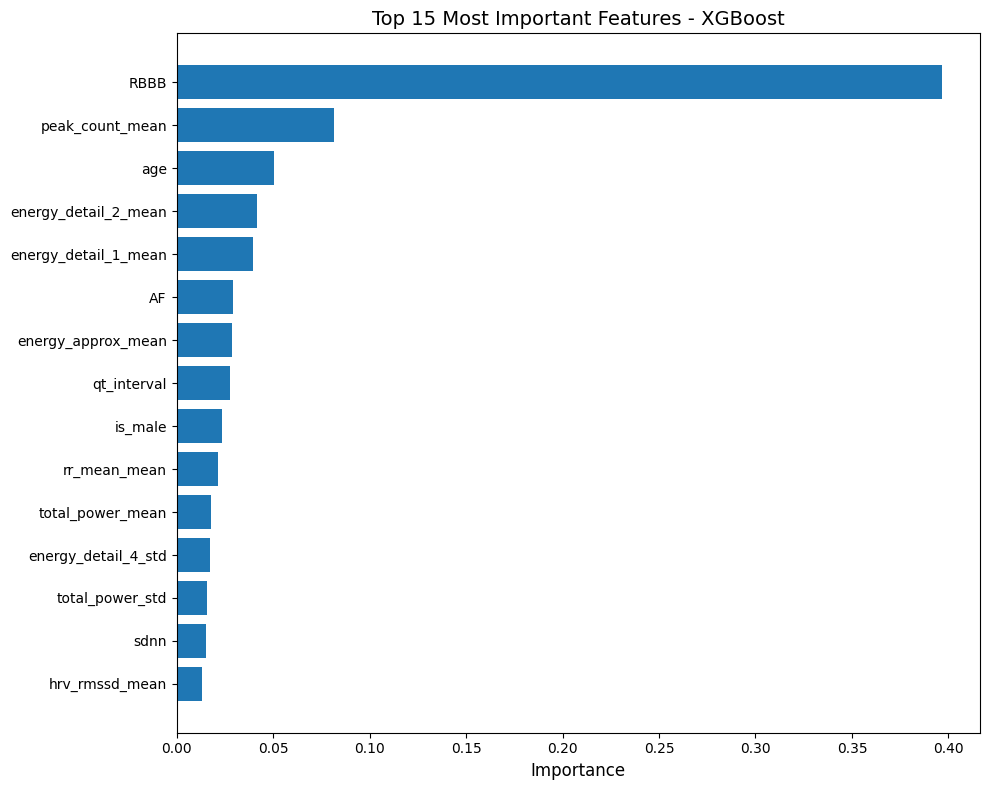

In [13]:
plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features["Importance"])
plt.yticks(range(len(top_features)), top_features["Feature"])
plt.xlabel("Importance", fontsize=12)
plt.title("Top 15 Most Important Features - XGBoost", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



 ## 12. Final XGBoost Model Summary

In [ ]:
summary_df = pd.DataFrame({
    "Dataset": [
        "Validation - default threshold 0.5",
        "Validation - selected threshold by F2",
        "Test - default threshold 0.5",
        "Test - selected threshold by F2"
    ],
    "Threshold": [
        0.5,
        best_threshold,
        0.5,
        best_threshold
    ],
    "ROC-AUC": [
        val_roc_auc,
        val_roc_auc,
        test_roc_auc,
        test_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        val_pr_auc,
        test_pr_auc,
        test_pr_auc
    ],
    "Balanced Accuracy": [
        val_balanced_acc_default,
        val_balanced_acc_selected,
        test_balanced_acc_default,
        test_balanced_acc_selected
    ],
    "F1-score": [
        val_f1_default,
        val_f1_selected,
        test_f1_default,
        test_f1_selected
    ],
    "F2-score": [
        val_f2_default,
        val_f2_selected,
        test_f2_default,
        test_f2_selected
    ],
    "Precision": [
        val_precision_default,
        val_precision_selected,
        test_precision_default,
        test_precision_selected
    ],
    "Recall": [
        val_recall_default,
        val_recall_selected,
        test_recall_default,
        test_recall_selected
    ]
})


print(summary_df.to_string(index=False))

print("\nBest hyperparameters selected by validation PR-AUC:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nSelected threshold by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by validation PR-AUC:")
print(results_df[display_cols].head(10).to_string(index=False))

FINAL XGBOOST PERFORMANCE SUMMARY
                              Dataset  Threshold  ROC-AUC   PR-AUC  Balanced Accuracy  F1-score  F2-score  Precision   Recall
   Validation - default threshold 0.5   0.500000 0.837712 0.170038           0.598001  0.238120  0.219109   0.278375 0.208036
Validation - selected threshold by F2   0.286923 0.837712 0.170038           0.670268  0.219864  0.297253   0.153331 0.388393
         Test - default threshold 0.5   0.500000 0.832663 0.160473           0.608128  0.246860  0.235515   0.268409 0.228514
      Test - selected threshold by F2   0.286923 0.832663 0.160473           0.674069  0.199495  0.285116   0.132952 0.399393

Best hyperparameters selected by validation PR-AUC:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 3
  min_child_weight: 1
  n_estimators: 700
  scale_pos_weight: 7.269035452141803
  subsample: 1.0

Selected threshold by validation F2: 0.2869

Top 10 hyperparameter combinations by validation PR-AUC:
 colsample_bytree  lea

In [47]:
xgb_predictions = pd.DataFrame({
    "exam_id": df.loc[X_test.index, "exam_id"] if "exam_id" in df.columns else X_test.index,
    "y_true": y_test.values,
    "y_prob_xgb": y_test_prob_best
})

xgb_predictions.to_csv("xgb_test_predictions.csv", index=False)

## 13. MODEL COMPARISON

In [48]:
logreg = pd.read_csv("logreg_test_predictions.csv")
rf = pd.read_csv("rf_test_predictions.csv")
xgb = pd.read_csv("xgb_test_predictions.csv")

preds = (
    logreg
    .merge(rf, on=["exam_id", "y_true"], how="inner")
    .merge(xgb, on=["exam_id", "y_true"], how="inner")
)

print(preds.shape)
print(preds.head())
assert preds["y_true"].nunique() == 2

(51247, 5)
   exam_id  y_true  y_prob_logreg  y_prob_rf  y_prob_xgb
0  2873686       0       0.168444   0.096608    0.072396
1  2950575       0       0.140335   0.096413    0.107878
2  1409062       0       0.027288   0.006133    0.015173
3  2918812       0       0.006377   0.007194    0.003973
4   247114       0       0.124981   0.030642    0.029108


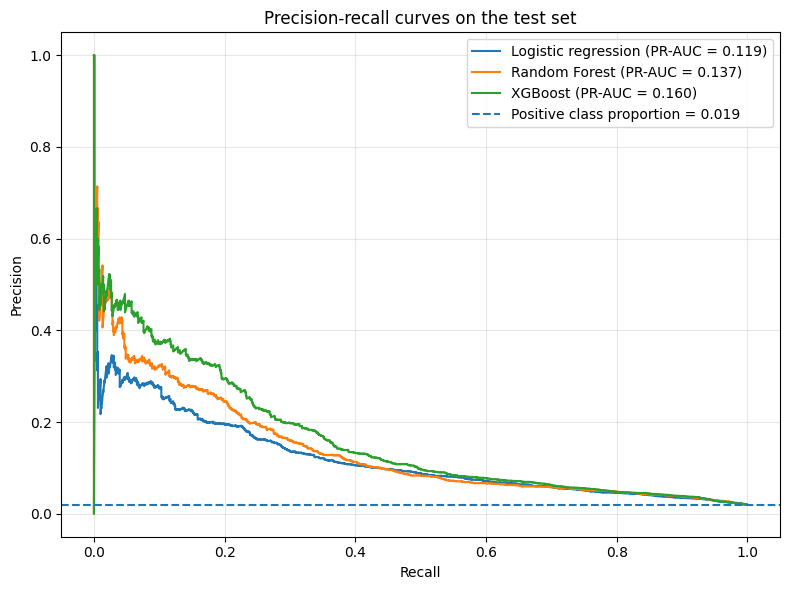

In [49]:
models = {
    "Logistic regression": "y_prob_logreg",
    "Random Forest": "y_prob_rf",
    "XGBoost": "y_prob_xgb"
}

plt.figure(figsize=(8, 6))

for model_name, prob_col in models.items():
    precision, recall, _ = precision_recall_curve(
        preds["y_true"],
        preds[prob_col]
    )

    pr_auc = average_precision_score(
        preds["y_true"],
        preds[prob_col]
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
    )

baseline = preds["y_true"].mean()
plt.axhline(
    baseline,
    linestyle="--",
    label=f"Positive class proportion = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on the test set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("model_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

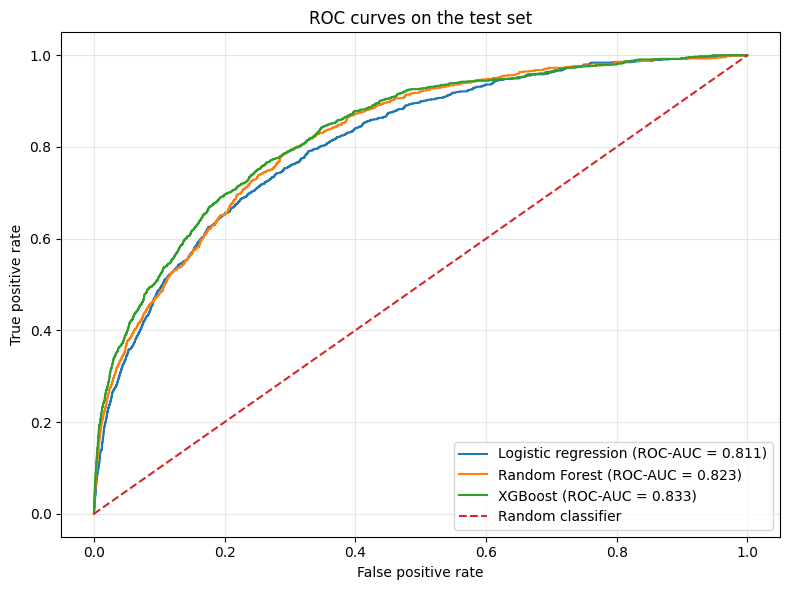

In [19]:
plt.figure(figsize=(8, 6))

for model_name, prob_col in models.items():
    fpr, tpr, _ = roc_curve(
        preds["y_true"],
        preds[prob_col]
    )

    roc_auc = roc_auc_score(
        preds["y_true"],
        preds[prob_col]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (ROC-AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on the test set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("model_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Learning curves

In [ ]:
train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

learning_curve_results = []

for size in train_sizes:
    if size < 1.0:
        gss = GroupShuffleSplit(
            n_splits=1,
            train_size=size,
            random_state=42
        )

        subset_idx, _ = next(
            gss.split(
                X_train,
                y_train,
                groups=groups_train
            )
        )

        X_train_part = X_train.iloc[subset_idx].copy()
        y_train_part = y_train.iloc[subset_idx].copy()

    else:
        X_train_part = X_train.copy()
        y_train_part = y_train.copy()

    model = clone(best_model)
    model.fit(X_train_part, y_train_part)

    y_train_prob = model.predict_proba(X_train_part)[:, 1]
    y_val_prob = model.predict_proba(X_val)[:, 1]

    train_pr_auc = average_precision_score(y_train_part, y_train_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    learning_curve_results.append({
        "train_fraction": size,
        "n_train_samples": len(X_train_part),
        "n_positive_train": int(y_train_part.sum()),
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)

print(learning_curve_df)

   train_fraction  n_train_samples  n_positive_train  train_pr_auc  val_pr_auc
0            0.10            24032               432      0.740172    0.108938
1            0.25            60101              1142      0.412021    0.148251
2            0.50           119699              2265      0.278917    0.163280
3            0.75           179761              3354      0.247561    0.164716
4            1.00           239583              4450      0.225701    0.170038


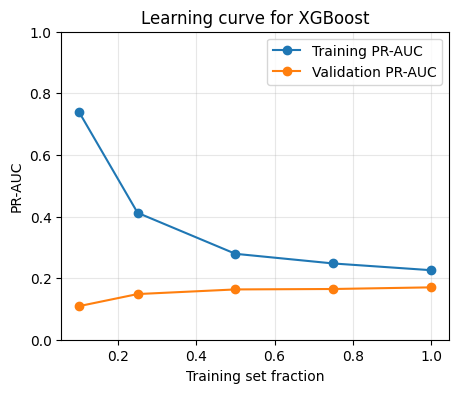

In [31]:
plt.figure(figsize=(5, 4))

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["train_pr_auc"],
    marker="o",
    label="Training PR-AUC"
)

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Training set fraction")
plt.ylabel("PR-AUC")
plt.title("Learning curve for XGBoost")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def pr_auc_scorer(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    return average_precision_score(y, y_prob)


perm_result = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring=pr_auc_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

importance_df.head(20)

,feature,importance_mean,importance_std
31,RBBB,0.062659,0.002065
16,energy_detail_2_mean,0.056562,0.003496
29,age,0.044037,0.004627
0,peak_count_mean,0.040073,0.003402
30,is_male,0.012010,0.002712
12,energy_approx_mean,0.008016,0.001315
6,hrv_rmssd_mean,0.007195,0.002280
26,qt_interval,0.006014,0.002490
5,rr_std_std,0.005930,0.001584
14,energy_detail_1_mean,0.005615,0.002133


## Feature importance

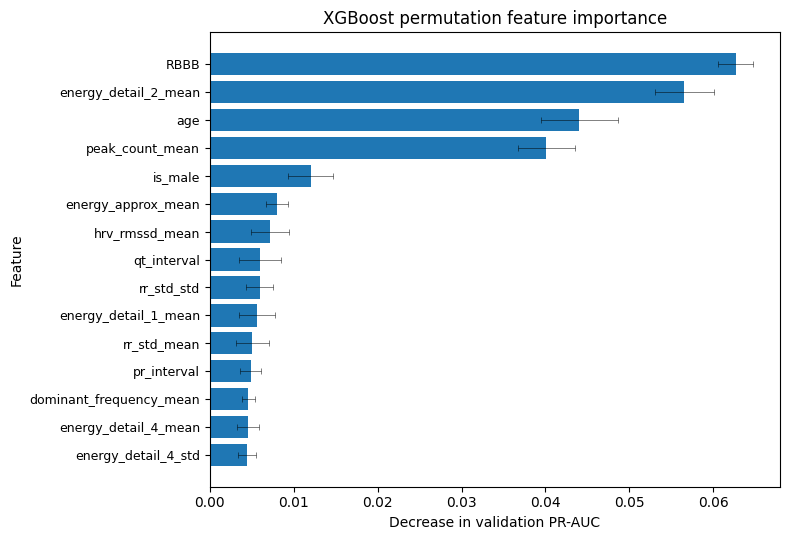

In [38]:
top_n = 15

top_features = importance_df.head(top_n).sort_values(
    by="importance_mean",
    ascending=True
)

plt.figure(figsize=(8, 5.5))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    error_kw={
        "elinewidth": 0.7,
        "capsize": 2,
        "capthick": 0.7,
        "alpha": 0.5
    }
)

plt.xlabel("Decrease in validation PR-AUC")
plt.ylabel("Feature")
plt.title("XGBoost permutation feature importance")
plt.tick_params(axis="y", labelsize=9)
plt.tight_layout()

plt.savefig("xgboost_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
y_test_prob_xgb = best_model.predict_proba(X_test)[:, 1]
best_threshold_xgb = 0.287
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_prob"] = y_test_prob_xgb
error_df["y_pred"] = (error_df["y_prob"] >= best_threshold_xgb).astype(int)

conditions = [
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 1),
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 0)
]

choices = ["TP", "FN", "FP", "TN"]

error_df["error_group"] = np.select(
    conditions,
    choices,
    default="Unknown"
)
error_df["error_group"].value_counts()

error_group
TN    47684
FP     2574
FN      594
TP      395
Name: count, dtype: int64

## Error analysis

In [43]:
important_features = [
    "RBBB",
    "energy_detail_2_mean",
    "age",
    "peak_count_mean",
    "is_male",
    "energy_approx_mean"
]

error_summary = error_df.groupby("error_group")[important_features + ["y_prob"]].mean()

print(error_summary)

                 RBBB  energy_detail_2_mean        age  peak_count_mean  \
error_group                                                               
FN           0.023569            707.933671  61.715488         8.772287   
FP           0.275447            524.148428  63.887723         7.901077   
TN           0.011094            793.285905  52.366727         9.971177   
TP           0.473418            443.405086  62.392405         7.828914   

              is_male  energy_approx_mean    y_prob  
error_group                                          
FN           0.387205         1519.732493  0.145641  
FP           0.367521         1692.986299  0.428579  
TN           0.405482         1673.043510  0.069557  
TP           0.435443         1819.547839  0.562688  


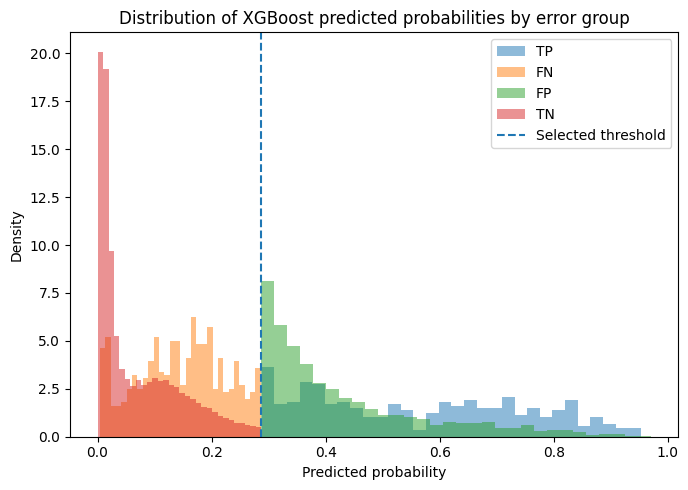

In [ ]:
plt.figure(figsize=(7, 5))

for group in ["TP", "FN", "FP", "TN"]:
    subset = error_df[error_df["error_group"] == group]
    plt.hist(
        subset["y_prob"],
        bins=30,
        alpha=0.5,
        label=group,
        density=True
    )

plt.axvline(
    best_threshold_xgb,
    linestyle="--",
    label="Selected threshold"
)

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Distribution of XGBoost predicted probabilities by error group")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
error_summary = (
    error_df
    .groupby("error_group")[important_features + ["y_prob"]]
    .agg(["mean", "median"])
)

error_summary

RBBB        energy_detail_2_mean                    age  \
                 mean median                 mean      median       mean   
error_group                                                                
FN           0.023569    0.0           707.933671  737.202131  61.715488   
FP           0.275447    0.0           524.148428  528.872787  63.887723   
TN           0.011094    0.0           793.285905  800.090760  52.366727   
TP           0.473418    0.0           443.405086  411.384501  62.392405   

                   peak_count_mean             is_male         \
            median            mean    median      mean median   
error_group                                                     
FN            62.0        8.772287  8.083333  0.387205    0.0   
FP            66.0        7.901077  7.916667  0.367521    0.0   
TN            53.0        9.971177  9.833333  0.405482    0.0   
TP            64.0        7.828914  7.666667  0.435443    0.0   

            energy_approx_mean                 y_prob            
                          mean       median      mean    median  
error_group                                                      
FN                 1519.732493  1424.970462  0.145641  0.150167  
FP                 1692.986299  1635.649505  0.428579  0.374466  
TN                 1673.043510  1590.144344  0.069557  0.034481  
TP                 1819.547839  1814.010782  0.562688  0.549771